# Workflow Test: Vacuum Gripper
### Geometries, Gripper, Grasp Sampler

In [1]:
import os
from os.path import join as pjoin
import sys
import numpy as np
import open3d as o3d
import yaml
from copy import deepcopy

# Import our custom modules
# from src.grippers.vacuum_gripper import VacuumGripper, VacuumGripperConfig
from src.grippers.vacuum_gripper_v2 import VacuumGripper, VacuumGripperConfig
# from src.grasping.vacuum_sampler import VacuumGraspSampler, VacuumSamplerConfig
from src.grasping.vacuum_sampler_v2 import VacuumGraspSampler, VacuumSamplerConfig
import src.utils.geometry_utils as gu
from src.generic_geometry import GenericGeometry


### Load Configs and data

In [2]:
# franka_path = pjoin("gripper_parameter", "double_quad_cup.yaml")
# franka_path = pjoin("gripper_parameter", "double_quad_cup_2.yaml")
franka_path = pjoin("gripper_parameter", "double_cup.yaml")
# franka_path = pjoin("gripper_parameter", "single_circle_cup.yaml")
# franka_path = pjoin("gripper_parameter", "franka_vacuum.yaml")

# object_path = pjoin("Test_part", "pringles", "clouds","merged_cloud.ply")
object_path = pjoin("Test_part","Verification_examples","combined.ply")

gripper = VacuumGripper(franka_path)
pcd = GenericGeometry(object_path)
pcd.estimate_normals(align_direction=np.array([0,0,1]))

✅ Geometry set: mesh (open3d)
Applying rigid transformation...
🔧 Vacuum Gripper 'Double_Schmalz_ECG' initialized.
   - Active Pads: 2
[Open3D WARNING] geometry::TriangleMesh appears to be a geometry::PointCloud (only contains vertices, but no triangles).
[Open3D] Loaded PointCloud: Test_part/Verification_examples/combined.ply
✅ Geometry set: point_cloud (open3d)
Estimating normals (radius=None, k=30)...


PointCloud with 30000 points.

In [3]:
gripper.visualize()

In [4]:
pcd.visualize()

## Create Grasp Sampler

In [3]:
# 2. Initialize Sampler Configuration
sampler_config = VacuumSamplerConfig(
    num_samples=1200,        # Cast 300 rays
    approach_distance=0.15, # 15cm approach check
    local_clearence_margin=0.02,
    safety_volume_shape= "bounding_box_shape",
    max_angle_deg=45,
    min_score=0.1,           # Minimum GSS to accept
    # rotation_strategy='uniform', # 'uniform' or 'fixed'
    rotation_strategy='uniform', # 'uniform' or 'fixed'
    rotation_step_deg=10,
    rotation_range_deg=180,
    score_aggregation_method="median",
    debug_score=True

)

# 3. Initialize Sampler
sampler = VacuumGraspSampler(gripper, sampler_config)

[VacuumSampler] Using Contact Strategy: projection


### Downsample and Clean

In [4]:
dim_report = pcd.get_dimensions_report()
print("Object dimensions report:")
for k,v in dim_report.items():
    print(f"  {k}: {v}")

Object dimensions report:
  extents_xyz: [0.1    0.1023 0.0959]
  diagonal: 0.1722
  likely_unit: meters
  suggested_voxel_size: 0.00172
  details: Type: Open3D PointCloud. Size: 0.10 x 0.10 x 0.10. Unit: METERS.


In [39]:
# GenericGeometry(geometry=gripper.generate_safety_collision_mesh(
#     np.array([0,0,0]),
#     np.array([0,0,1]),
#     0.2
# )).visualize()

In [6]:
voxel_size = 0.002
pcd_down = pcd.downsample(voxel_size=voxel_size)
pcd_down = GenericGeometry(geometry=pcd_down)
pcd_down.visualize()

Downsampling with voxel_size=0.002...
✅ Geometry set: point_cloud (open3d)


In [21]:
pcd_down.clean_point_cloud(inplace=True, )

pcd_down.visualize()

✅ Geometry set: point_cloud (open3d)
[Clean] Points before processing: 17233
[Clean] Points after full cleaning: 17233
✅ Geometry set: point_cloud (open3d)


### Sample Grasps

In [7]:
# Run the sampling pipeline
# pcd_down = pcd.downsample(voxel_size=0.003)
grasps = sampler.sample_grasps(pcd_down.geometry)

print(f"\nResult: Found {len(grasps)} valid grasps.")

if len(grasps) > 0:
    best_grasp = grasps[0]
    print(f"Top Grasp Score: {best_grasp.score:.4f}")
    print(f"Top Grasp Position: {best_grasp.contact_point}")
else:
    print("No valid grasps found. Check thresholds.")

[Debug] Abrindo Visualizador de Raycasting...
[VacuumSampler] Phase 1: Generated 13832 candidates.
[Debug] Candidate failed verticality check: angle_deg = 59.044066603064614
[Debug] Candidate failed verticality check: angle_deg = 59.044066603064614
[Debug] Candidate failed verticality check: angle_deg = 59.044066603064614
[Debug] Candidate failed verticality check: angle_deg = 59.044066603064614
[Debug] Candidate failed verticality check: angle_deg = 59.044066603064614
[Debug] Candidate failed verticality check: angle_deg = 59.044066603064614
[Debug] Candidate failed verticality check: angle_deg = 59.044066603064614
[Debug] Candidate failed verticality check: angle_deg = 59.044066603064614
[Debug] Candidate failed verticality check: angle_deg = 59.044066603064614
[Debug] Candidate failed verticality check: angle_deg = 59.044066603064614
[Debug] Candidate failed verticality check: angle_deg = 59.044066603064614
[Debug] Candidate failed verticality check: angle_deg = 59.044066603064614
[

In [42]:
# for c in sampler.get_best_candidates(8):
for c in [best_grasp]:
# for c in [sampler.candidates[50]]:
    sampler.visualize_grasp(pcd_down.geometry, c)

✅ Geometry set: mesh (open3d)
Applying rigid transformation...


<Axes: ylabel='Count'>

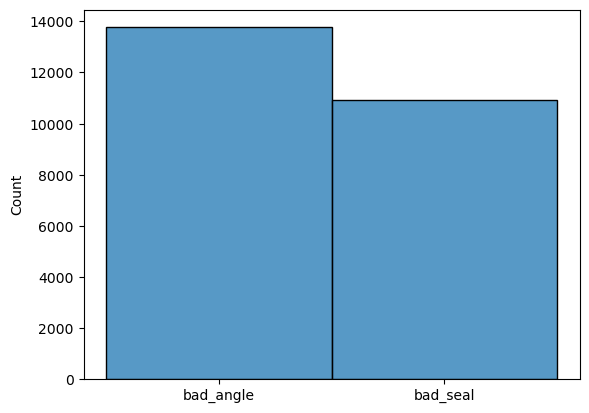

In [16]:
import seaborn as sns
reasons = [c.score_details.get("failure_reason", []) for c in sampler.candidates]
reasons = sum(reasons, start=[])
sns.histplot(reasons)

In [17]:

# # for c in sampler.get_best_candidates(8):
for c in sampler.valid_candidates[:5]:
# # for c in [sampler.candidates[50]]:
    sampler.visualize_grasp(pcd_down.geometry, c)

✅ Geometry set: mesh (open3d)
Applying rigid transformation...
✅ Geometry set: mesh (open3d)
Applying rigid transformation...
✅ Geometry set: mesh (open3d)
Applying rigid transformation...
✅ Geometry set: mesh (open3d)
Applying rigid transformation...
✅ Geometry set: mesh (open3d)
Applying rigid transformation...


(array([9391.,  107.,  149.,  151.,  183.,  249.,  293.,  360.,  373.,
         360.,  313.,  210.,  185.,  176.,  282.,  191.,  159.,  136.,
          49.,   21.]),
 array([0.        , 0.04829268, 0.09658537, 0.14487805, 0.19317073,
        0.24146341, 0.2897561 , 0.33804878, 0.38634146, 0.43463415,
        0.48292683, 0.53121951, 0.5795122 , 0.62780488, 0.67609756,
        0.72439024, 0.77268293, 0.82097561, 0.86926829, 0.91756098,
        0.96585366]),
 <BarContainer object of 20 artists>)

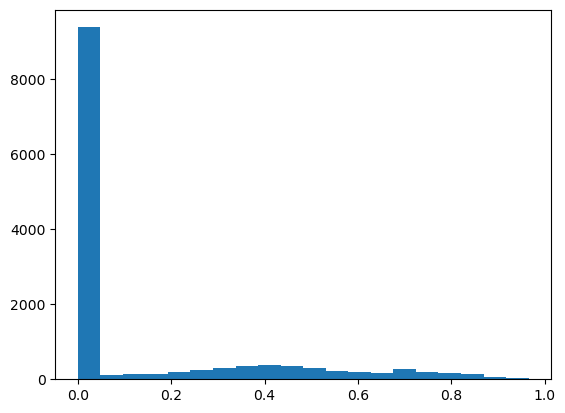

In [31]:
import matplotlib.pyplot as plt
plt.hist(list(map(lambda c: c.score_details.get("seal_score") , sampler.candidates)), bins=20)

In [44]:
sampler.visualize_candidates_heatmap(pcd_down.geometry, valid_only=False)

In [43]:
sampler.visualize_candidates_heatmap(pcd_down.geometry,attribute='verticality', valid_only=False, relative_scale=False)

In [14]:
sampler.visualize_candidates_heatmap(pcd_down.geometry,attribute='torque', valid_only=False, )

In [15]:
sampler.visualize_candidates_heatmap(pcd_down.geometry,attribute='seal_score', valid_only=False)